In [47]:
from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from pydantic import BaseModel, Field
from typing import TypedDict, Literal
from dotenv import load_dotenv
from operator import add

In [48]:
load_dotenv()

True

In [49]:
llm = ChatAnthropic(model="claude-haiku-4-5-20251001")

In [50]:
class State(TypedDict):
    age:int
    remark:str

In [51]:
graph = StateGraph(State)

In [52]:
def router(state:State)->Literal['adult', 'young']:
    if state['age'] > 17:
        return 'adult'
    else:
        return 'young'

In [53]:
def adult(state:State):
    return {'remark':"able to vote"}

In [54]:
def young(state:State):
    return {'remark':"too young not able to vote"}

In [55]:
graph.add_node('adult', adult)
graph.add_node('young', young)

In [56]:
graph.add_conditional_edges(START, router)
graph.add_edge('adult', END)
graph.add_edge('young', END)

In [57]:
workflow = graph.compile()

In [58]:
workflow.invoke({'age':9})

{'age': 9, 'remark': 'too young not able to vote'}

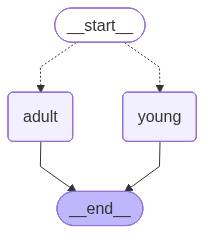

In [59]:
workflow